# Create AnnData from Xenium output folders

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import seaborn as sns
import math
import session_info

In [2]:
plt.rcParams['figure.dpi'] = 150

## Set paths

In [3]:
data_input_folder = '/home/workspace/projects/drg/download/isolon' # where current data is

base_dir = '/home/workspace/projects/drg' 
fig_dir = os.path.join(base_dir, 'figures/qc/') # where to save qc viz
h5ad_dir = os.path.join(base_dir, 'data/h5ad/export_01/01_raw/output_folder') # where to save anndata
metadata_dir = os.path.join(base_dir, 'metadata')

os.makedirs(base_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)
os.makedirs(h5ad_dir, exist_ok=True)
os.makedirs(metadata_dir, exist_ok=True)


In [4]:
sample_id_mapping = {
    "output-XETG00123__0052281__TMA00303__20251108__004334": "TMA00303",
    "output-XETG00123__0052334__TMA00304__20251108__004334": "TMA00304",
    "output-XETG00123__0052281__TMA00305__20251108__004334": "TMA00305",
    "output-XETG00123__0052334__TMA00306__20251108__004334": "TMA00306"
}

## Functions

In [5]:
def h5_to_adata(directory, sample_id):
    # File names    
    h5_file = os.path.join(directory, 'cell_feature_matrix.h5')
    cells_file = os.path.join(directory, 'cells.csv.gz')

    # h5 to adata
    adata = sc.read_10x_h5(
        filename=h5_file
    )

    # cells file
    df = pd.read_csv(
        cells_file, 
        compression='gzip'
    )

    # Set index
    df.set_index(adata.obs_names, inplace=True)
    adata.obs = df.copy()

    # x, y coordinates
    adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

    # Add sample metadata
    adata.obs['output_id'] = sample_id

    return adata

## Create sample dictionary

In [6]:
directory_to_sample = {
    os.path.join(data_input_folder, subdir): f"{subdir}"
    for subdir in os.listdir(data_input_folder) if os.path.isdir(os.path.join(data_input_folder, subdir))
    if os.path.isdir(os.path.join(data_input_folder, subdir)) and not subdir.startswith(".")  # Excludes hidden folders like .ipynb_checkpoints
}

print(directory_to_sample)

{'/home/workspace/projects/drg/download/isolon/output-XETG00123__0052281__TMA00305__20251108__004334': 'output-XETG00123__0052281__TMA00305__20251108__004334', '/home/workspace/projects/drg/download/isolon/output-XETG00123__0052281__TMA00303__20251108__004334': 'output-XETG00123__0052281__TMA00303__20251108__004334', '/home/workspace/projects/drg/download/isolon/output-XETG00123__0052334__TMA00304__20251108__004334': 'output-XETG00123__0052334__TMA00304__20251108__004334', '/home/workspace/projects/drg/download/isolon/output-XETG00123__0052334__TMA00306__20251108__004334': 'output-XETG00123__0052334__TMA00306__20251108__004334'}


## Create anndata

In [7]:
# Loop through each key-value pair in the dictionary
adata_list = []
for directory, xenium_run_id in directory_to_sample.items():
    print(f"Processing: {directory} -> Run ID: {xenium_run_id}")
    adata = h5_to_adata(directory, xenium_run_id)
    adata.obs["xenium_run_id"] = xenium_run_id  
    adata_list.append(adata)

Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0052281__TMA00305__20251108__004334 -> Run ID: output-XETG00123__0052281__TMA00305__20251108__004334
Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0052281__TMA00303__20251108__004334 -> Run ID: output-XETG00123__0052281__TMA00303__20251108__004334
Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0052334__TMA00304__20251108__004334 -> Run ID: output-XETG00123__0052334__TMA00304__20251108__004334
Processing: /home/workspace/projects/drg/download/isolon/output-XETG00123__0052334__TMA00306__20251108__004334 -> Run ID: output-XETG00123__0052334__TMA00306__20251108__004334


In [8]:
# Annotate sample ID based on xenium output folder name

sample_id_mapping =  sample_id_mapping

# Apply the mapping to adata.obs["xenium_run_id"]
for adata in adata_list:
    adata.obs["output_id"] = adata.obs["xenium_run_id"].map(sample_id_mapping)
    print(adata.obs[["xenium_run_id", "output_id"]].head(3))

                                                xenium_run_id output_id
aaaaicce-1  output-XETG00123__0052281__TMA00305__20251108_...  TMA00305
aaadbjoi-1  output-XETG00123__0052281__TMA00305__20251108_...  TMA00305
aaafchgj-1  output-XETG00123__0052281__TMA00305__20251108_...  TMA00305
                                                xenium_run_id output_id
aaagciof-1  output-XETG00123__0052281__TMA00303__20251108_...  TMA00303
aaailodo-1  output-XETG00123__0052281__TMA00303__20251108_...  TMA00303
aaanacfp-1  output-XETG00123__0052281__TMA00303__20251108_...  TMA00303
                                                xenium_run_id output_id
aaacpmhc-1  output-XETG00123__0052334__TMA00304__20251108_...  TMA00304
aaadagcf-1  output-XETG00123__0052334__TMA00304__20251108_...  TMA00304
aaaihgjh-1  output-XETG00123__0052334__TMA00304__20251108_...  TMA00304
                                                xenium_run_id output_id
aaaackia-1  output-XETG00123__0052334__TMA00306__20251108_...  T

## QC

In [9]:
adata_list

[AnnData object with n_obs × n_vars = 38753 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 12755 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id'
     var: 'gene_ids', 'feature_types', 'genome'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 24375 × 480
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts'

#### Fix order

In [10]:
#desired_order = ["TIS09471_Control", "TIS09474_Trpv1+"]

#adata_list = sorted(adata_list, key=lambda ad: desired_order.index(ad.obs['output_id'].iloc[0]))

#### Visualize

TMA00305
38753 cells
TMA00303
12755 cells
TMA00304
24375 cells
TMA00306
37315 cells


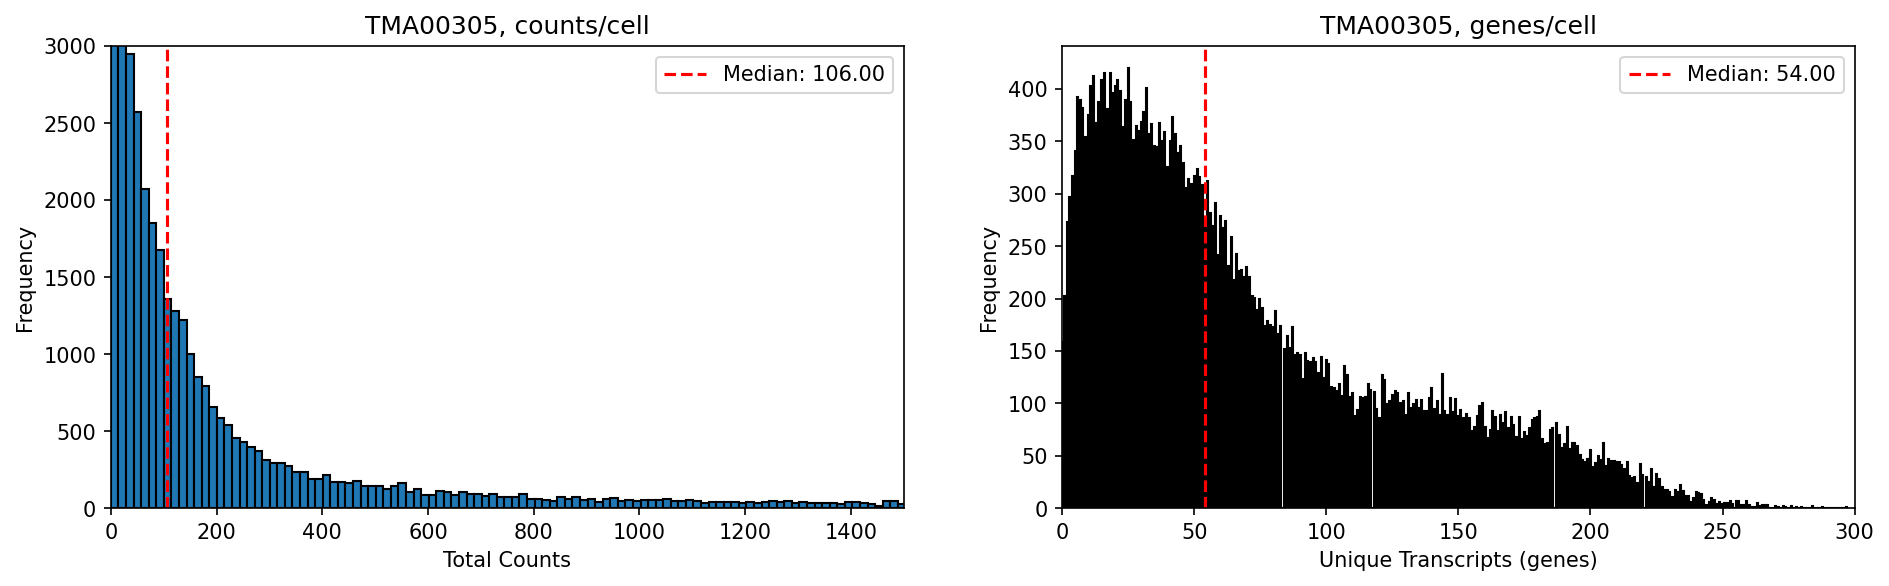

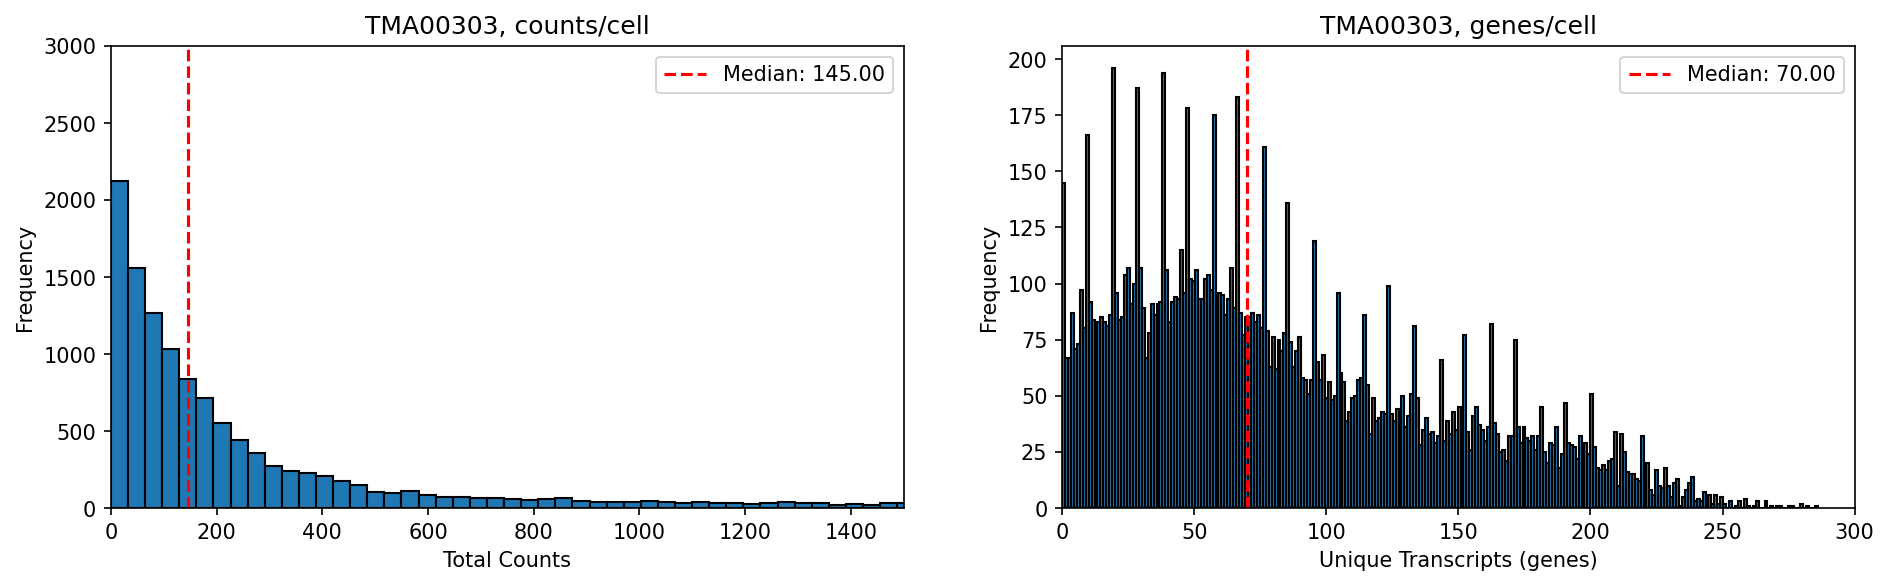

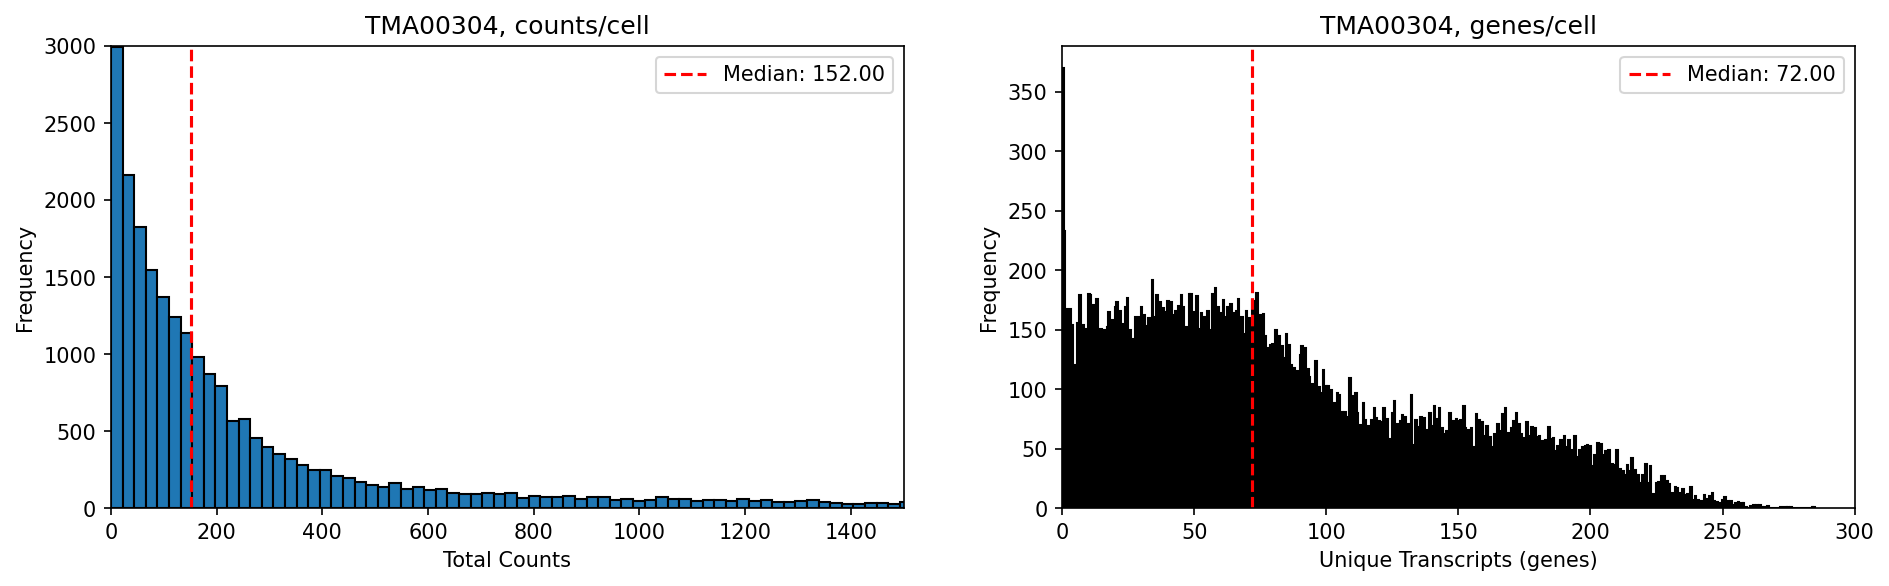

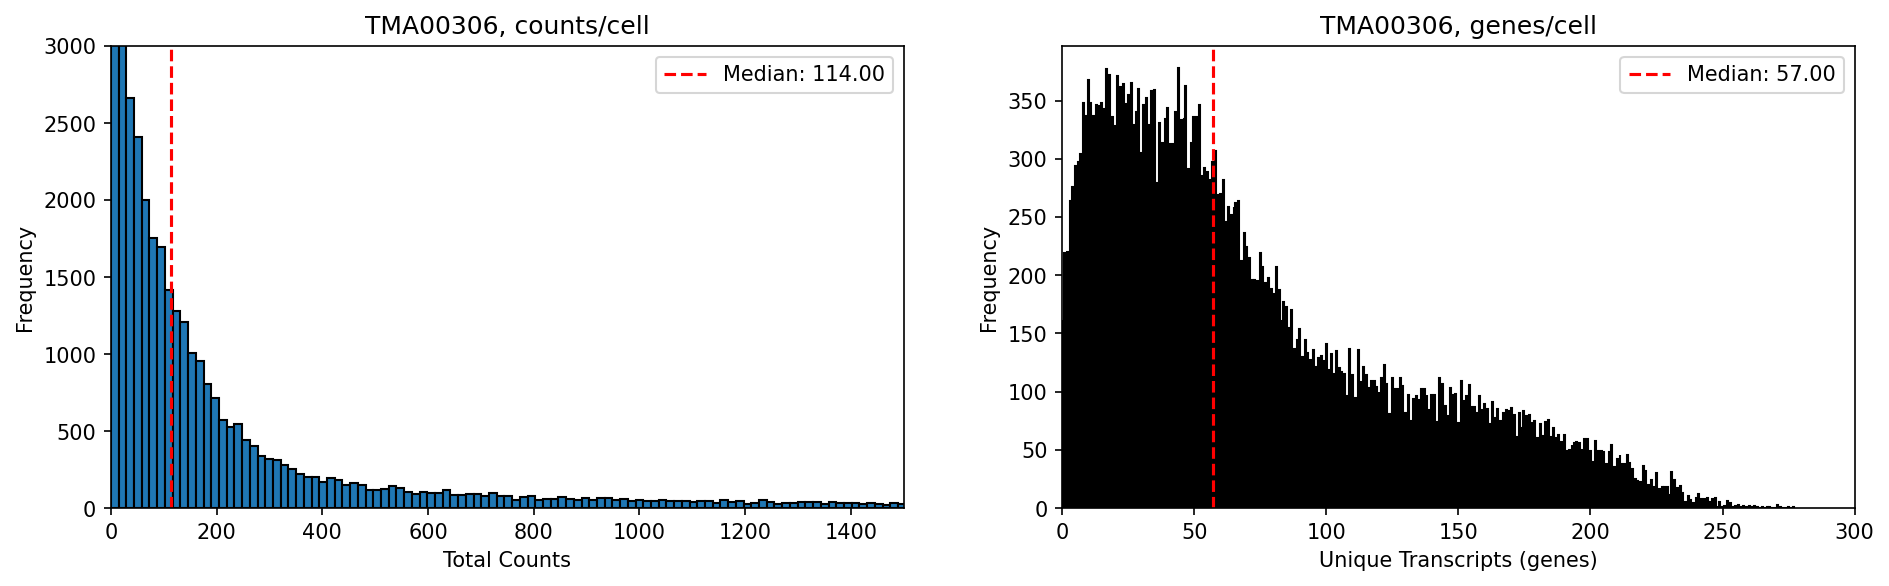

In [11]:
for adata in adata_list:
    sample_id = adata.obs['output_id'].iloc[0]
    print(sample_id)

    # Calculate QC
    sc.pp.calculate_qc_metrics(adata, percent_top=(10, 20, 50, 150), inplace=True)

    # Number of cells
    cell_num = adata.obs.shape[0]
    print(cell_num, 'cells')

    # Visualize QC
    fig, axs = plt.subplots(1, 2, figsize=(15, 4))

    # Plot the first histogram: Total Counts
    counts_median = adata.obs["total_counts"].median()  
    axs[0].hist(adata.obs["total_counts"], bins=math.ceil(cell_num / 50), edgecolor='black')
    axs[0].set_title(sample_id + ", " + "counts/cell")
    axs[0].set_xlim(0, 1500)
    axs[0].set_ylim(0, 3000)
    axs[0].set_xlabel('Total Counts')
    axs[0].set_ylabel('Frequency')
    axs[0].axvline(counts_median, color='red', linestyle='--', label=f'Median: {counts_median:.2f}')  # Add vertical line
    axs[0].legend()  # Add legend for the median line

    # Plot the second histogram: Genes by Counts
    genes_median = adata.obs["n_genes_by_counts"].median()  
    axs[1].hist(adata.obs["n_genes_by_counts"], bins=math.ceil(cell_num / 50), edgecolor='black')
    axs[1].set_title(sample_id + ", " + "genes/cell")
    axs[1].set_xlim(0, 300)
    axs[1].set_xlabel('Unique Transcripts (genes)')
    axs[1].set_ylabel('Frequency')
    axs[1].axvline(genes_median, color='red', linestyle='--', label=f'Median: {genes_median:.2f}')  # Add vertical line
    axs[1].legend()  # Add legend for the median line

    # Save figure
    fig.savefig(os.path.join(fig_dir, sample_id + '_raw_QC.png'))

In [12]:
#for adata in adata_list:
#    sc.pl.violin(adata, ['total_counts', 'n_genes_by_counts'])

TMA00305


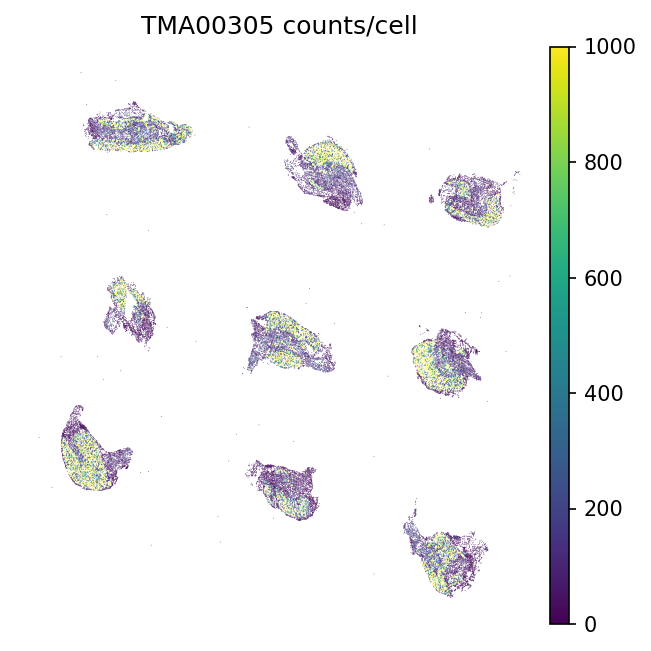

TMA00303


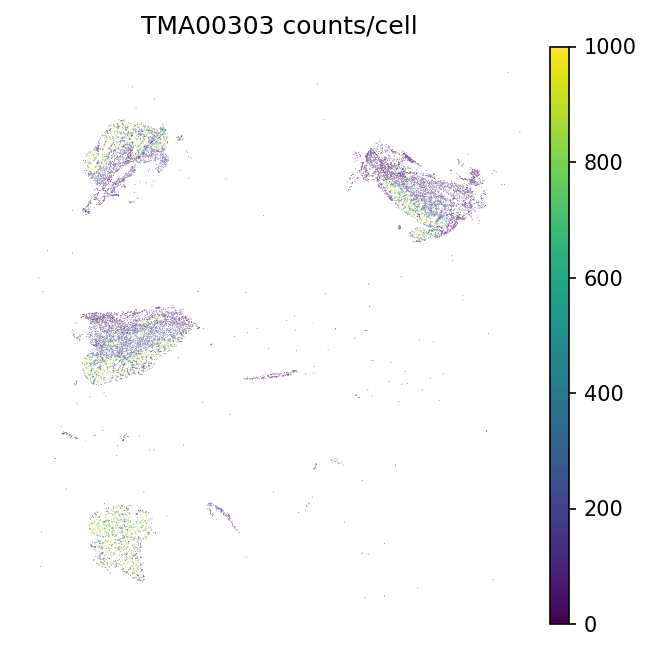

TMA00304


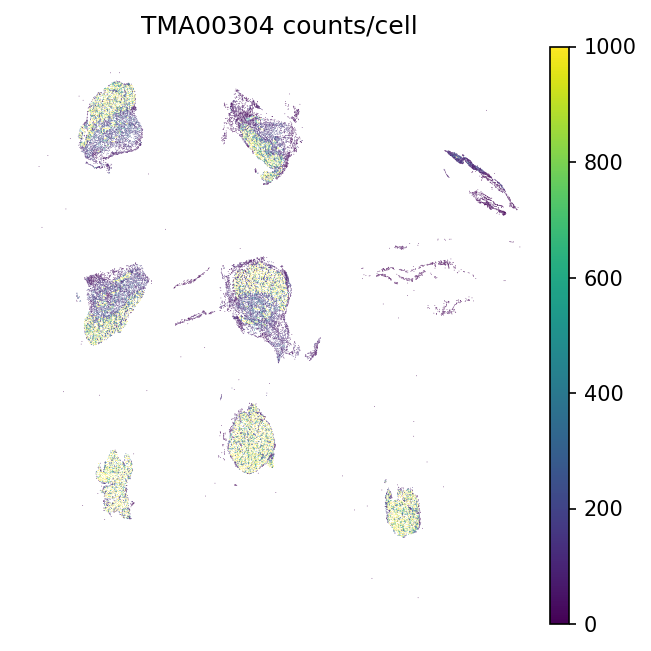

TMA00306


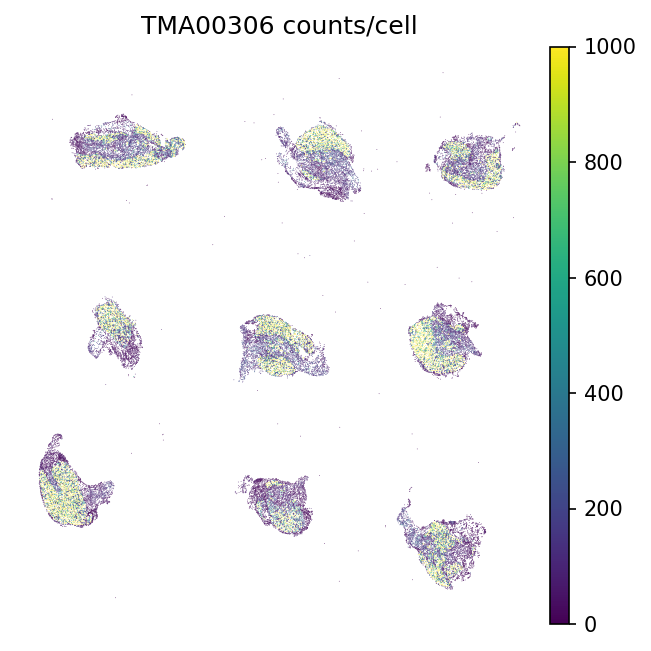

In [13]:
# spatial qc

for adata in adata_list:
    sample_id = adata.obs['output_id'].iloc[0]
    print(sample_id)

    fig, ax = plt.subplots(figsize=(5, 5))
    sc.pl.embedding(adata, basis='spatial', color='total_counts', title=sample_id + ' counts/cell',
                    vmin=0, vmax=1000, size=0.5, ax=ax, frameon = False)  # Pass ax explicitly

    fig.savefig(os.path.join(fig_dir, sample_id + '_spatial_QC.png'))
    plt.close(fig)

## Genes of interest

In [14]:
genes = adata.var
genes.head()

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
1500009L16Rik,ENSMUSG00000087651,Gene Expression,Unknown,2129,0.083103,0.079830,94.294520,3101.0,8.039803
6330403K07Rik,ENSMUSG00000018451,Gene Expression,Unknown,11508,4.505320,1.705715,69.159855,168116.0,12.032415
Abcb1a,ENSMUSG00000040584,Gene Expression,Unknown,7032,0.533217,0.427368,81.155031,19897.0,9.898375
Ache,ENSMUSG00000023328,Gene Expression,Unknown,8883,1.745947,1.010126,76.194560,65150.0,11.084463
Acta2,ENSMUSG00000035783,Gene Expression,Unknown,1614,0.082460,0.079236,95.674662,3077.0,8.032035


In [15]:
# save panel
csv_path = os.path.join(metadata_dir, 'gene-panel.csv')
genes.to_csv(csv_path, index = True)

print(f'Gene panel saved at: {csv_path}')

Gene panel saved at: /home/workspace/projects/drg/metadata/gene-panel.csv


In [16]:
#genes_of_interest = ['Epcam', 'Acta2', 'Ptprc',
#                     'Cd19', 'Cd3e', 'Trpv1']

In [17]:
#for adata in adata_list:
#    sample_id = adata.obs['output_id'].iloc[0]
#    print(sample_id)
#    sc.pl.embedding(adata, basis='spatial', color=genes_of_interest,
#                    size=0.5,
#                    ncols=3
#                   ) 

## Export Anndata

In [18]:
# export 01

for i, adata in enumerate(adata_list):
    sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"
    output_file = os.path.join(h5ad_dir, f"{sample_name}.h5ad")
    
    adata.write(output_file)
    print(f"Saved: {output_file}")

Saved: /home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder/TMA00305.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder/TMA00303.h5ad


/tmp/ipykernel_2726/3662922147.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_2726/3662922147.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"
/tmp/ipykernel_2726/3662922147.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[p

Saved: /home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder/TMA00304.h5ad
Saved: /home/workspace/projects/drg/data/h5ad/export_01/01_raw/output_folder/TMA00306.h5ad


/tmp/ipykernel_2726/3662922147.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_name = adata.obs["output_id"][0] if "output_id" in adata.obs.columns else f"sample_{i+1}"


### Session info

In [19]:
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active conda environment: sc-spatial
